# Portfolio + System: explore, forecast, dispatch

End-to-end view of the prototype:

1. **Data** — synthetic portfolio (C&I sites: load + rooftop solar) and the surrounding GB **system mix** (national wind / nuclear / CCGT / biomass / hydro / interconnectors / solar; GB has been coal-free since 30 Sep 2024).
2. **Forecast** — point + q10/q90 band of the portfolio's grid-facing net (`load − rooftop solar`), in MWh per SP.
3. **Dispatch** — LP battery schedule committed against the point forecast.
4. **Risk bounds** — same committed schedule, settled against the q10 and q90 realisations to bracket the cost.

> Reminder: the portfolio's only self-supply source is **solar** (plus the battery). Other generation in the mix is system context that drives **prices**, not portfolio physical net.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import data, forecast, loop

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

## 1. Build the portfolio + system mix

Flip `USE_REAL_DATA` below to switch the GB system mix + prices between **synthetic** (runs anywhere) and **real** public Elexon data (`FUELHH` mix + `system-prices` cash-out + `MID` day-ahead proxy — run *locally*; the sandbox can't reach Elexon). C&I site load/solar stay synthetic either way: no open per-site C&I data exists, and that gap is exactly the proprietary moat a real product fills.

In [2]:
# ── Data source toggle ───────────────────────────────────────────────────────
# False -> synthetic (runs anywhere). True -> REAL GB mix + prices from public
# Elexon datasets over [DATE_FROM, DATE_TO] (run LOCALLY; the sandbox can't reach
# Elexon). Use >= ~3 weeks so the forecaster has lag features + a holdout.
USE_REAL_DATA = False
DATE_FROM, DATE_TO = "2025-01-06", "2025-01-27"   # YYYY-MM-DD, only used if real

if USE_REAL_DATA:
    p = data.build_portfolio(n_sites=5, seed=0, real=True,
                             date_from=DATE_FROM, date_to=DATE_TO)
else:
    p = data.build_portfolio(n_sites=5, days=21, seed=0)

print("Source:       ", "REAL (Elexon)" if USE_REAL_DATA else "SYNTHETIC")
print("Sites:        ", list(p["sites"].keys()))
print("Days x HH:    ", len(p["index"]), "periods,",
      p["index"][0], "→", p["index"][-1])
print("Mix columns:  ", list(p["mix"].columns))
p["sites"]["site_0"].head(3).round(1)

Source:        SYNTHETIC
Sites:         ['site_0', 'site_1', 'site_2', 'site_3', 'site_4']
Days x HH:     1008 periods, 2026-01-06 00:00:00 → 2026-01-26 23:30:00
Mix columns:   ['demand_mw', 'wind_mw', 'nuclear_mw', 'biomass_mw', 'hydro_mw', 'solar_mw', 'interconnector_mw', 'ccgt_mw', 'vre_mw', 'vre_share', 'residual_demand_mw']


,solar_kw,load_kw,solar_mwh,load_mwh
2026-01-06 00:00:00,0.0,66.5,0.0,0.0
2026-01-06 00:30:00,0.0,62.8,0.0,0.0
2026-01-06 01:00:00,0.0,67.2,0.0,0.0


## 2. The GB generation mix (system context — drives prices, not portfolio net)

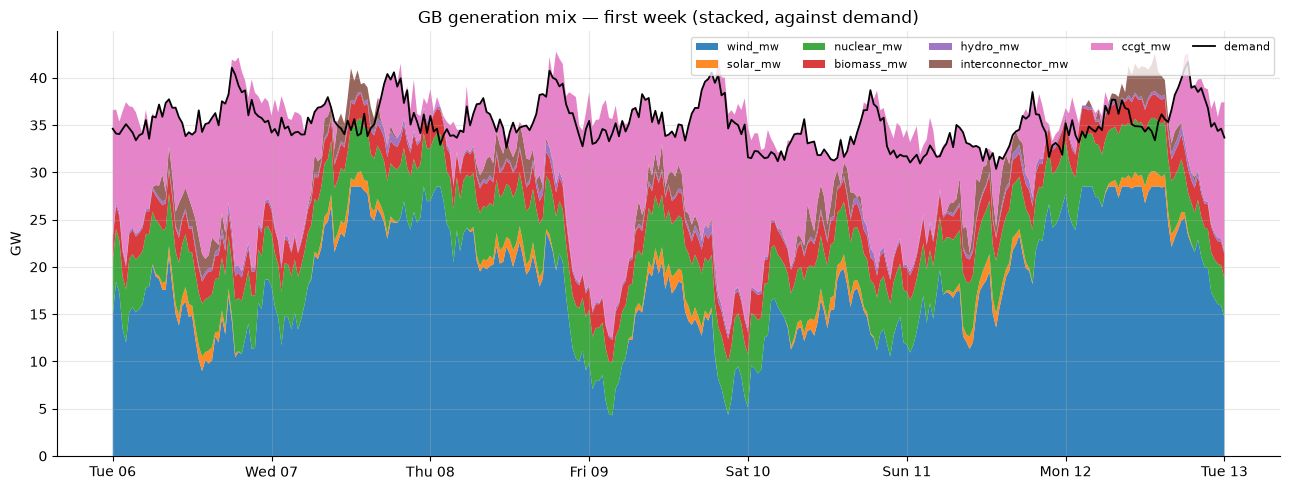

In [3]:
mix = p["mix"]
fuels = ["wind_mw", "solar_mw", "nuclear_mw", "biomass_mw", "hydro_mw",
         "interconnector_mw", "ccgt_mw"]   # GB coal-free since 30 Sep 2024
window = slice(mix.index[0], mix.index[0] + pd.Timedelta(days=7))
m_gw = mix.loc[window, fuels].clip(lower=0) / 1000  # MW → GW

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(m_gw.index, m_gw.T.values, labels=fuels, alpha=0.9)
ax.plot(mix.loc[window].index, mix.loc[window, "demand_mw"] / 1000,
        color="k", lw=1.3, label="demand")
ax.set(ylabel="GW", title="GB generation mix — first week (stacked, against demand)")
ax.legend(loc="upper right", ncol=5, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
plt.tight_layout(); plt.show()

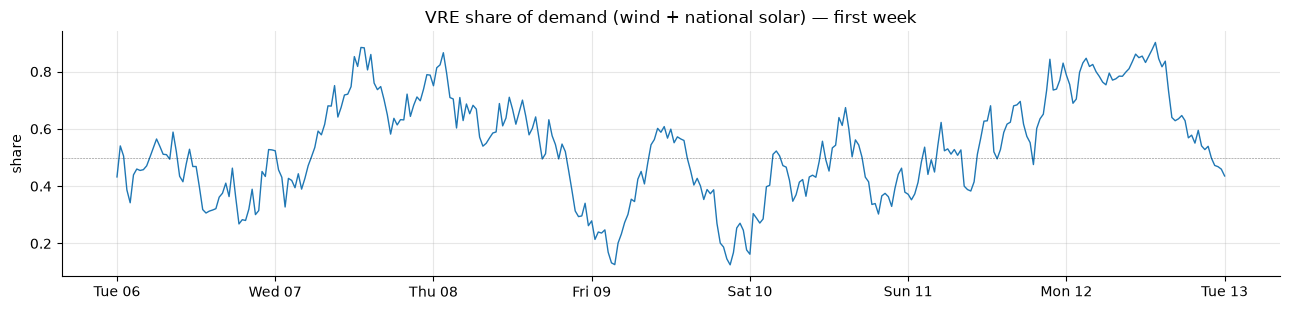

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(mix.loc[window].index, mix.loc[window, "vre_share"], lw=1)
ax.axhline(0.5, color="k", lw=0.4, ls="--", alpha=0.5)
ax.set(ylabel="share", title="VRE share of demand (wind + national solar) — first week")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
plt.tight_layout(); plt.show()

## 3. Prices: where the mix actually bites

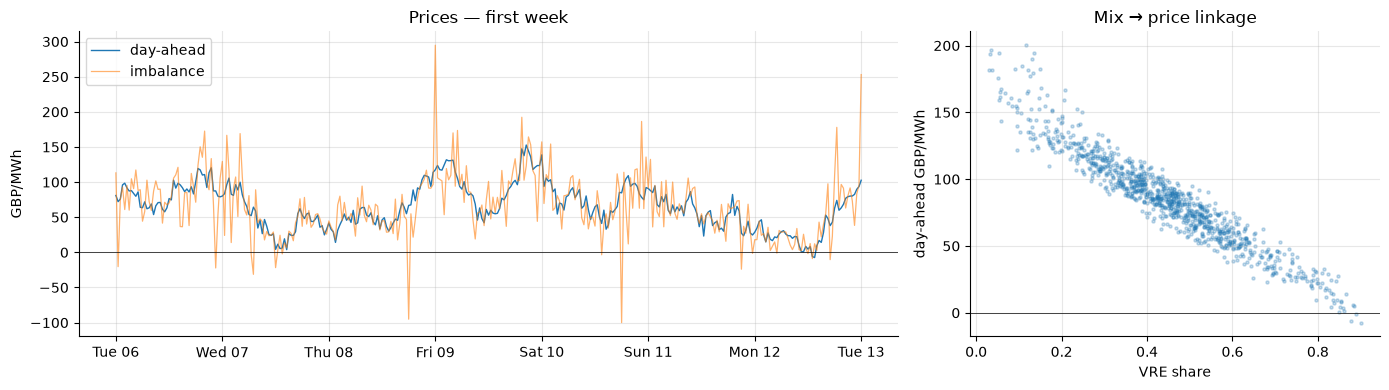

Day-ahead price summary (GBP/MWh):
count    1008.0
mean       85.5
std        34.1
min        -7.4
25%        63.3
50%        85.9
75%       105.7
max       200.3

Imbalance price summary (GBP/MWh):
count    1008.0
mean       87.8
std        51.8
min      -100.0
25%        53.5
50%        81.7
75%       112.2
max       349.4


In [5]:
price = p["price"]
pw = price.loc[window]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4),
                                gridspec_kw={"width_ratios": [2, 1]})
ax1.plot(pw.index, pw["day_ahead"], label="day-ahead", lw=1)
ax1.plot(pw.index, pw["imbalance"], label="imbalance", lw=0.9, alpha=0.6)
ax1.axhline(0, color="k", lw=0.5)
ax1.set(ylabel="GBP/MWh", title="Prices — first week")
ax1.legend(); ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

ax2.scatter(mix["vre_share"], price["day_ahead"], s=5, alpha=0.25)
ax2.set(xlabel="VRE share", ylabel="day-ahead GBP/MWh",
        title="Mix → price linkage")
ax2.axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

print("Day-ahead price summary (GBP/MWh):")
print(price["day_ahead"].describe().round(1).to_string())
print("\nImbalance price summary (GBP/MWh):")
print(price["imbalance"].describe().round(1).to_string())

## 4. The portfolio (customer side) — load + rooftop solar

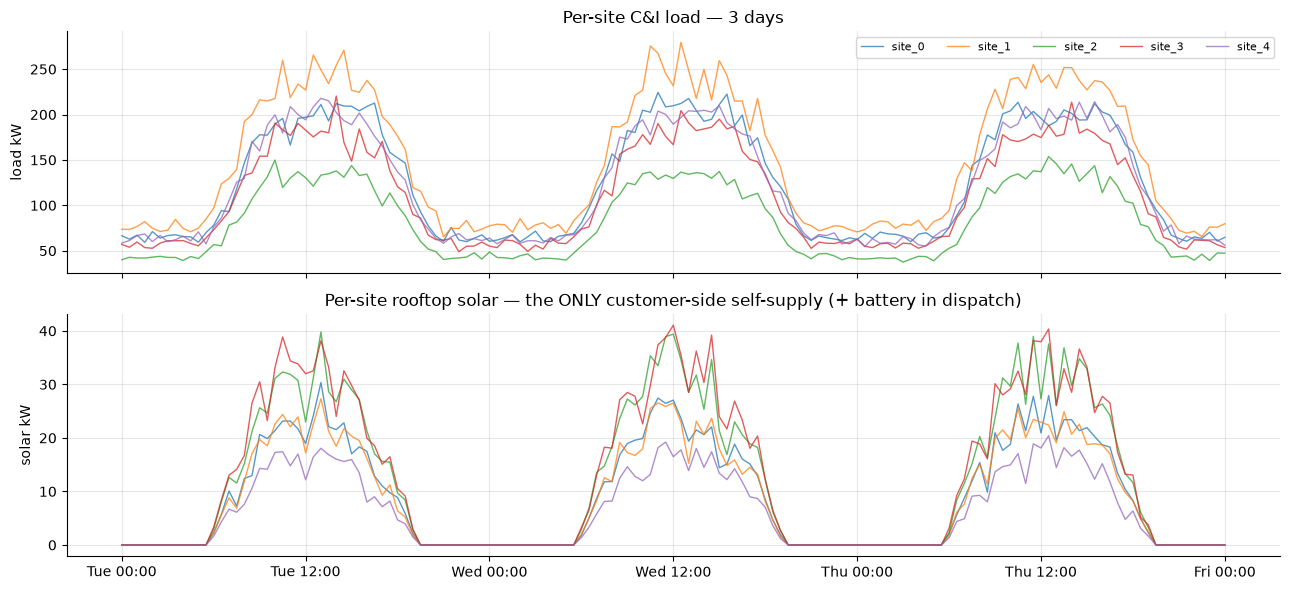

In [6]:
sites = p["sites"]
day3 = slice(p["index"][0], p["index"][0] + pd.Timedelta(days=3))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for name, s in sites.items():
    axes[0].plot(s.loc[day3].index, s.loc[day3, "load_kw"], lw=1, label=name, alpha=0.75)
    axes[1].plot(s.loc[day3].index, s.loc[day3, "solar_kw"], lw=1, label=name, alpha=0.75)
axes[0].set(ylabel="load kW", title="Per-site C&I load — 3 days")
axes[1].set(ylabel="solar kW",
            title="Per-site rooftop solar — the ONLY customer-side self-supply (+ battery in dispatch)")
axes[0].legend(ncol=5, fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
plt.tight_layout(); plt.show()

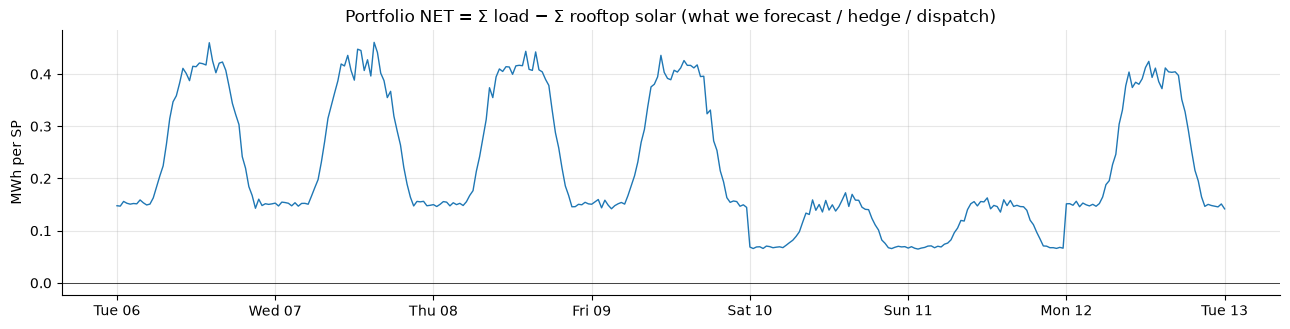

Net portfolio summary (MWh per SP):
count    1008.0000
mean        0.2180
std         0.1196
min         0.0631
25%         0.1428
50%         0.1562
75%         0.3514
max         0.4606


In [7]:
net = forecast.portfolio_net_mwh(p)

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.plot(net.loc[window].index, net.loc[window].values, lw=1, color="C0")
ax.axhline(0, color="k", lw=0.5)
ax.set(ylabel="MWh per SP",
       title="Portfolio NET = Σ load − Σ rooftop solar (what we forecast / hedge / dispatch)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
plt.tight_layout(); plt.show()

print("Net portfolio summary (MWh per SP):")
print(net.describe().round(4).to_string())

## 5. Forecast — point + q10/q90 quantile band

Features mix calendar/lag terms with system context (day-ahead price; lagged imbalance, VRE share, residual demand, national wind/solar). Quantile bands come from separate `GradientBoostingRegressor(loss="quantile", alpha=q)` models — they're the uncertainty signal the dispatcher / risk view consumes downstream.

In [8]:
ctx = forecast.ctx_from_portfolio(p)
fc, metrics = forecast.train_forecast(net, ctx=ctx, test_days=3)
pd.Series(metrics, name="value").to_frame().round(3)

,value
MAE_model_mwh,0.011
MAE_naive_mwh,0.111
RMSE_model_mwh,0.016
pinball_q10_mwh,0.004
pinball_q90_mwh,0.003
improvement_vs_naive_%,90.000


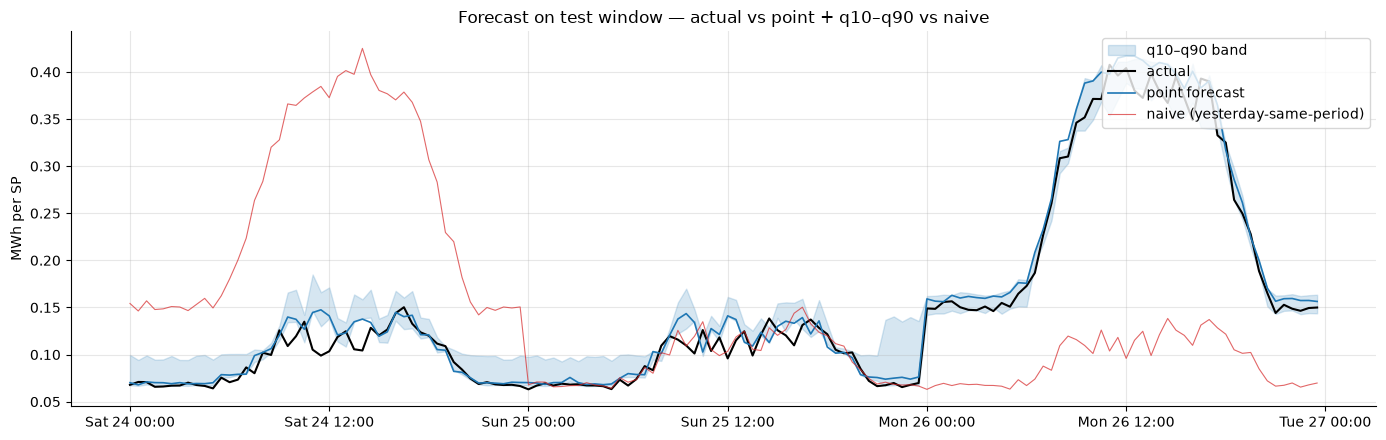

In [9]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(fc.index, fc["q10"], fc["q90"], color="C0", alpha=0.18,
                label="q10–q90 band")
ax.plot(fc.index, fc["actual"], color="k", lw=1.5, label="actual")
ax.plot(fc.index, fc["point"], color="C0", lw=1.2, label="point forecast")
ax.plot(fc.index, fc["naive"], color="C3", lw=0.8, alpha=0.7,
        label="naive (yesterday-same-period)")
ax.set(ylabel="MWh per SP",
       title="Forecast on test window — actual vs point + q10–q90 vs naive")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %H:%M"))
plt.tight_layout(); plt.show()

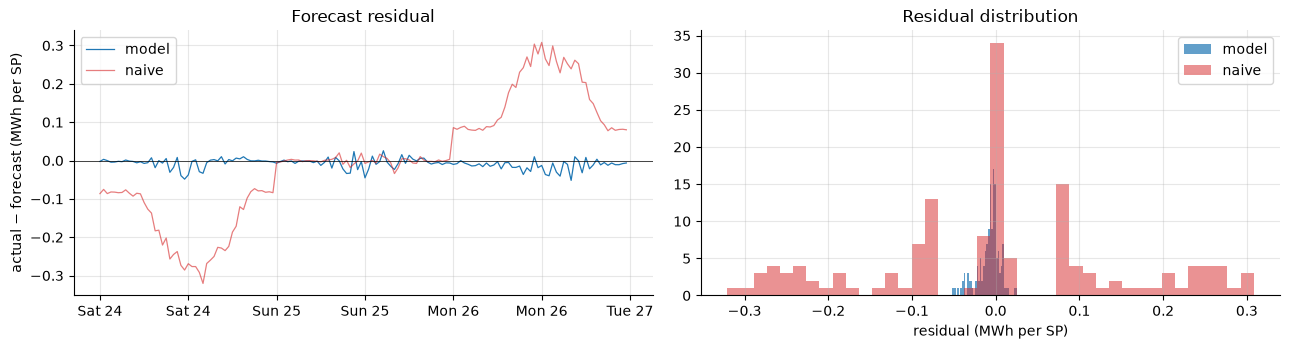

In [10]:
# residuals
resid_pt = fc["actual"] - fc["point"]
resid_nv = fc["actual"] - fc["naive"]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(resid_pt.index, resid_pt.values, lw=0.9, color="C0", label="model")
axes[0].plot(resid_nv.index, resid_nv.values, lw=0.9, color="C3", alpha=0.6, label="naive")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set(ylabel="actual − forecast (MWh per SP)", title="Forecast residual")
axes[0].legend(); axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

axes[1].hist(resid_pt, bins=40, alpha=0.7, label="model", color="C0")
axes[1].hist(resid_nv, bins=40, alpha=0.5, label="naive", color="C3")
axes[1].set(xlabel="residual (MWh per SP)", title="Residual distribution"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Dispatch — battery schedule on the point forecast

LP over the test window: minimise `Σ price · grid · Δt` s.t. SoC balance, rate / capacity limits, `grid = net + charge − discharge`. The schedule is COMMITTED on the forecast — actuals will deviate.

In [11]:
da = price["day_ahead"].reindex(fc.index)
imb = price["imbalance"].reindex(fc.index)

# fc carries MWh per SP; dispatch_lp wants SP-averaged power [kW] (primer §6.1)
KW_PER_MWH_PER_SP = 1000.0 / 0.5
disp = loop.dispatch_lp(fc["point"] * KW_PER_MWH_PER_SP, da)
disp.head(4).round(1)

,net_kw,charge_kw,discharge_kw,grid_kw,grid_mwh,soc_kwh
2026-01-24 00:00:00,140.3,250.0,0.0,390.3,0.2,365.0
2026-01-24 00:30:00,135.8,250.0,0.0,385.8,0.2,480.0
2026-01-24 01:00:00,142.0,0.0,0.0,142.0,0.1,480.0
2026-01-24 01:30:00,140.5,0.0,250.0,-109.5,-0.1,344.1


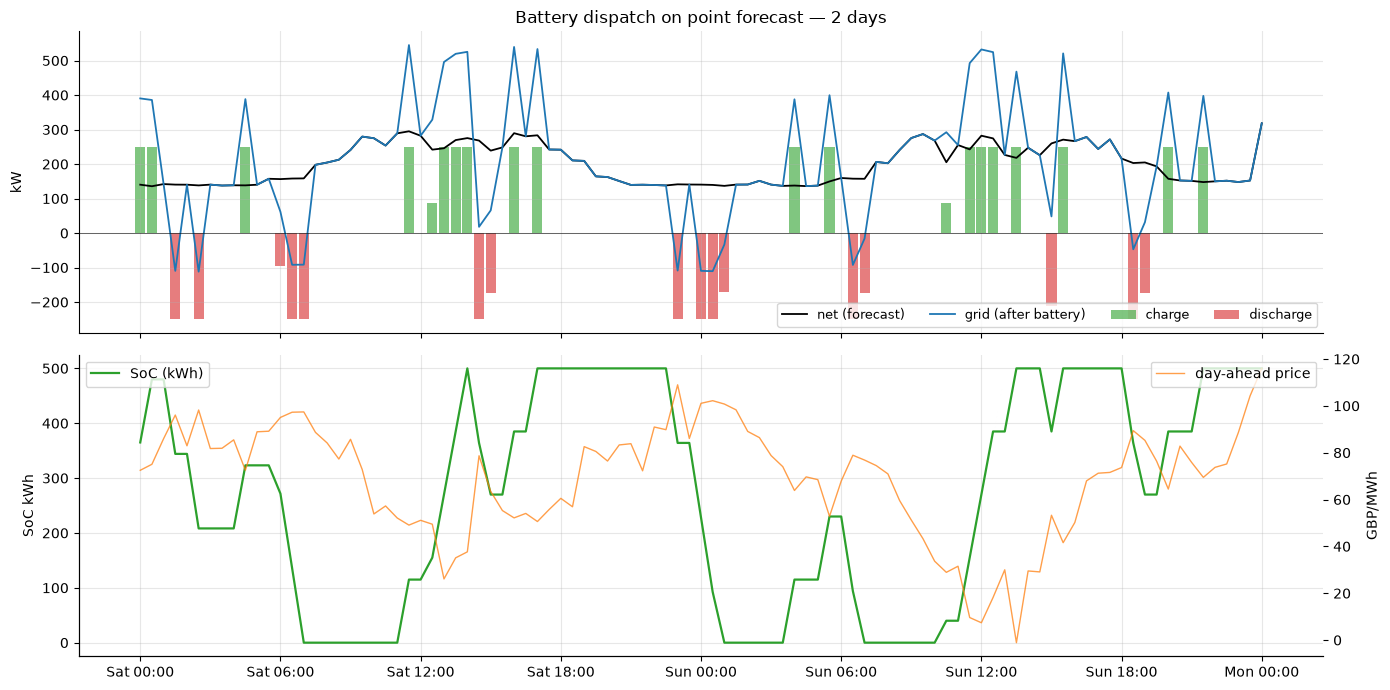

In [12]:
plot_day = slice(disp.index[0], disp.index[0] + pd.Timedelta(days=2))
d = disp.loc[plot_day]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(d.index, d["net_kw"], color="k", lw=1.3, label="net (forecast)")
ax1.plot(d.index, d["grid_kw"], color="C0", lw=1.3, label="grid (after battery)")
ax1.bar(d.index, d["charge_kw"], width=0.018, color="C2", alpha=0.6, label="charge")
ax1.bar(d.index, -d["discharge_kw"], width=0.018, color="C3", alpha=0.6, label="discharge")
ax1.axhline(0, color="k", lw=0.4)
ax1.set(ylabel="kW", title="Battery dispatch on point forecast — 2 days")
ax1.legend(ncol=4, fontsize=9)

ax2.plot(d.index, d["soc_kwh"], color="C2", lw=1.6, label="SoC (kWh)")
ax2.set(ylabel="SoC kWh")
ax2b = ax2.twinx()
ax2b.plot(d.index, da.loc[plot_day], color="C1", lw=1, alpha=0.75,
          label="day-ahead price")
ax2b.set(ylabel="GBP/MWh"); ax2b.grid(False)
ax2.legend(loc="upper left"); ax2b.legend(loc="upper right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
plt.tight_layout(); plt.show()

## 7. Risk bounds on the optimisation outcome

The schedule is committed on the **point** forecast. Settlement cost depends on what actually shows up. To bracket the risk, we re-settle the same committed schedule against three realisations:

- **actual** (what really happened in the test window),
- **q10** — an optimistically low realisation (less demand to cover),
- **q90** — a pessimistically high realisation (more demand than expected).

The spread between the q10 and q90 settlements is the cost-band implied by the forecast's uncertainty.

In [13]:
disp_point = loop.dispatch_lp(fc["point"] * KW_PER_MWH_PER_SP, da)

# Battery actions cross from the LP's kW world into the energy world ONCE here.
charge_mwh = loop._kw_to_mwh(disp_point["charge_kw"])
discharge_mwh = loop._kw_to_mwh(disp_point["discharge_kw"])

scenarios = {}
for label, actual_col in [("realised (actual)", "actual"),
                          ("q10 (low net)", "q10"),
                          ("q90 (high net)", "q90")]:
    scenarios[label] = loop.settle(
        disp_point["grid_mwh"], fc[actual_col], da, imb,
        charge_mwh=charge_mwh, discharge_mwh=discharge_mwh,
    )

cost_df = pd.DataFrame(scenarios).T[
    ["day_ahead_cost", "imbalance_cost", "total_cost", "abs_imbalance_mwh"]
].round(2)
cost_df

,day_ahead_cost,imbalance_cost,total_cost,abs_imbalance_mwh
realised (actual),1962.68,-97.57,1865.12,1.61
q10 (low net),1962.68,-153.27,1809.41,1.59
q90 (high net),1962.68,169.72,2132.40,2.40


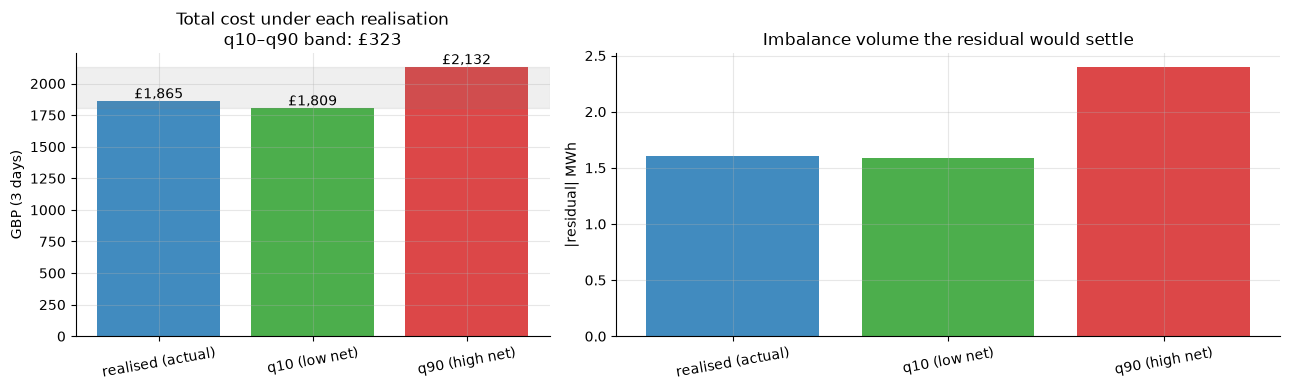

q10–q90 cost spread: £322.99
This spread is the cost-uncertainty band the forecast quantiles imply
— what a portfolio manager would size hedges / battery headroom against.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4),
                                gridspec_kw={"width_ratios": [1, 1.4]})

# total cost bars with q10–q90 risk band annotated
labels = list(cost_df.index)
totals = cost_df["total_cost"].values
colors = ["C0", "C2", "C3"]
bars = ax1.bar(labels, totals, color=colors, alpha=0.85)
for b, t in zip(bars, totals):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
             f"£{t:,.0f}", ha="center", fontsize=10)
q10_cost = cost_df.loc["q10 (low net)", "total_cost"]
q90_cost = cost_df.loc["q90 (high net)", "total_cost"]
ax1.axhspan(q10_cost, q90_cost, color="grey", alpha=0.12)
ax1.set(ylabel="GBP (3 days)",
        title=f"Total cost under each realisation\nq10–q90 band: £{q90_cost - q10_cost:,.0f}")

# imbalance MWh by scenario
ax2.bar(labels, cost_df["abs_imbalance_mwh"].values, color=colors, alpha=0.85)
ax2.set(ylabel="|residual| MWh",
        title="Imbalance volume the residual would settle")
for ax in (ax1, ax2):
    ax.tick_params(axis="x", labelrotation=10)
plt.tight_layout(); plt.show()

print(f"q10–q90 cost spread: £{q90_cost - q10_cost:,.2f}")
print("This spread is the cost-uncertainty band the forecast quantiles imply\n"
      "— what a portfolio manager would size hedges / battery headroom against.")

### Reading the band

- A **wide** q10–q90 band with **realised cost near the centre** = the model's uncertainty is honest. Hedge / battery headroom should be sized to the band, not the point.
- A **narrow** band with **realised cost outside it** = miscalibrated quantiles (test pinball loss would also flag this). The model is overconfident; widening it is cheaper than being surprised.
- On synthetic data here the band is small because the series is easy. Switching to real Elexon / PV Live data (see README) widens both the residual and the band — which is exactly when the forecaster's value becomes measurable in £.